# Sequential Bayesian A/B Test (Non-Paired)

Demo of `SequentialNonPairedBayesPropTest` from `bayesprop.resources.bayes_nonpaired`.

We observe Bernoulli outcomes from two arms **A** and **B** in batches over time and update the posterior after each batch. By Beta–Bernoulli conjugacy the running posterior

$$
\theta_A \mid \text{data} \sim \text{Beta}(\alpha_A^{(t)}, \beta_A^{(t)}), \qquad
\theta_B \mid \text{data} \sim \text{Beta}(\alpha_B^{(t)}, \beta_B^{(t)})
$$

is also the prior for the next batch, so four numbers per arm carry **all** the information needed for the Savage–Dickey Bayes factor on $\Delta = \theta_A - \theta_B$, the posterior probability $P(\theta_B > \theta_A)$, and a ROPE decision.

We stop as soon as the Bayes factor $\text{BF}_{10}$ crosses an upper or lower threshold, or when a maximum sample size is hit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bayesprop.resources.bayes_nonpaired import SequentialNonPairedBayesPropTest

rng = np.random.default_rng(42)

## 1. Simulate a stream of batches

Ground truth: $\theta_A = 0.75$, $\theta_B = 0.55$ (so a real effect of $\Delta = 0.20$ in favour of A). Each "look" delivers a small batch of 25 Bernoulli observations per arm, mimicking data arriving over time.

In [3]:
theta_A_true, theta_B_true = 0.75, 0.55
batch_size = 25
n_batches_max = 40

def stream():
    """Yield (y_a_batch, y_b_batch) pairs of binary observations."""
    for _ in range(n_batches_max):
        y_a = rng.binomial(1, theta_A_true, size=batch_size).astype(float)
        y_b = rng.binomial(1, theta_B_true, size=batch_size).astype(float)
        yield y_a, y_b

## 2. Configure the sequential test

- Uniform prior $\text{Beta}(1, 1)$ on each arm.
- Stop for $H_1$ when $\text{BF}_{10} \ge 10$ (strong evidence against $H_0: \Delta = 0$).
- Stop for $H_0$ when $\text{BF}_{10} \le 0.1$.
- `n_min = 30` per arm before any BF-based stopping (avoids unstable early BFs).
- Hard cap at `n_max = 1000` per arm.
- ROPE half-width $\varepsilon = 0.02$ (2 percentage points around $\Delta = 0$).

In [4]:
seq = SequentialNonPairedBayesPropTest(
    alpha0=1.0,
    beta0=1.0,
    bf_upper=10.0,
    bf_lower=0.1,
    n_min=30,
    n_max=1000,
    rope_epsilon=0.02,
    seed=0,
    n_samples=10_000,
    verbose=True,
)
seq.posterior_state

{'alpha_A': 1.0, 'beta_A': 1.0, 'alpha_B': 1.0, 'beta_B': 1.0}

## 3. Run the test on the stream

`update()` performs the conjugate posterior update and returns a snapshot for that look. We stop as soon as `seq.stopped` is true.

In [5]:
final = seq.run(stream())

print("\nStopped:", seq.stopped)
print("Reason :", seq.stop_reason)
print("Looks  :", len(seq.history))
print("Final n per arm:", final.n_A, final.n_B)

[look 1] n_A=25 n_B=25 P(B>A)=0.800 BF10=0.478 stop=False (None)
[look 2] n_A=50 n_B=50 P(B>A)=0.338 BF10=0.254 stop=False (None)
[look 3] n_A=75 n_B=75 P(B>A)=0.244 BF10=0.24 stop=False (None)
[look 4] n_A=100 n_B=100 P(B>A)=0.118 BF10=0.336 stop=False (None)
[look 5] n_A=125 n_B=125 P(B>A)=0.017 BF10=1.43 stop=False (None)
[look 6] n_A=150 n_B=150 P(B>A)=0.003 BF10=6.99 stop=False (None)
[look 7] n_A=175 n_B=175 P(B>A)=0.000 BF10=187 stop=True (BF10 ≥ 10.0 (evidence for H1))

Stopped: True
Reason : BF10 ≥ 10.0 (evidence for H1)
Looks  : 7
Final n per arm: 175 175


## 4. Inspect the final snapshot

The last `SequentialLookResult` carries:

- `posterior_state` — current $(\alpha_A, \beta_A, \alpha_B, \beta_B)$
- `P_B_greater_A` — analytic $P(\theta_B > \theta_A)$ via Gauss–Legendre quadrature
- `decision.bayes_factor` — Savage–Dickey $\text{BF}_{10}$ on $\Delta = 0$
- `decision.posterior_null` — $P(H_0 \mid \text{data})$
- `decision.rope` — ROPE classification

In [6]:
ps = final.posterior_state
print("Posterior state:")
print(f"  theta_A | data ~ Beta({ps.alpha_A:.0f}, {ps.beta_A:.0f})")
print(f"  theta_B | data ~ Beta({ps.alpha_B:.0f}, {ps.beta_B:.0f})")

print(f"\nP(theta_B > theta_A) = {final.P_B_greater_A:.4f}")

bf = final.decision.bayes_factor
print(f"\nSavage-Dickey BF_10 = {bf.BF_10:.3g}")
print(f"Savage-Dickey BF_01 = {bf.BF_01:.3g}")
print(f"Interpretation     : {bf.interpretation}")
print(f"Decision           : {bf.decision}")

rope = final.decision.rope
print(f"\nROPE [{rope.rope_lower:+.2f}, {rope.rope_upper:+.2f}]")
print(f"  95% CI on Delta: [{rope.ci_lower:+.3f}, {rope.ci_upper:+.3f}]")
print(f"  pct in ROPE   : {rope.pct_in_rope:.3f}")
print(f"  decision      : {rope.decision}")

Posterior state:
  theta_A | data ~ Beta(132, 45)
  theta_B | data ~ Beta(98, 79)

P(theta_B > theta_A) = 0.0001

Savage-Dickey BF_10 = 187
Savage-Dickey BF_01 = 0.00535
Interpretation     : Decisive evidence against H0
Decision           : Reject H0

ROPE [-0.02, +0.02]
  95% CI on Delta: [+0.095, +0.289]
  pct in ROPE   : 0.000
  decision      : Reject H0 — A practically better


## 5. Per-look history

`history_frame()` returns one row per look with the running posterior, $\text{BF}_{10}$, $P(\theta_B > \theta_A)$, and the stop flag.

In [7]:
df = seq.history_frame()
df

,look,n_A,n_B,alpha_A,beta_A,alpha_B,beta_B,P_B_gt_A,BF_10,BF_01,pct_in_rope,stop,stop_reason
0,1,25,25,14.0,13.0,17.0,10.0,0.799947,0.478106,2.091586,0.0818,False,NaN
1,2,50,50,35.0,17.0,33.0,19.0,0.338458,0.253684,3.941912,0.1551,False,NaN
2,3,75,75,54.0,23.0,50.0,27.0,0.243895,0.239663,4.172530,0.1682,False,NaN
3,4,100,100,71.0,31.0,63.0,39.0,0.117581,0.336450,2.972211,0.1153,False,NaN
4,5,125,125,91.0,36.0,75.0,52.0,0.016860,1.426269,0.701130,0.0294,False,NaN
5,6,150,150,112.0,40.0,89.0,63.0,0.002506,6.989893,0.143064,0.0069,False,NaN
6,7,175,175,132.0,45.0,98.0,79.0,0.000067,186.781793,0.005354,0.0003,True,BF10 ≥ 10.0 (evidence for H1)


## 6. Trajectory plot

Built-in plot: $\text{BF}_{10}$ (log scale) and $P(\theta_B > \theta_A)$ vs cumulative sample size, with stopping thresholds drawn as dashed lines.

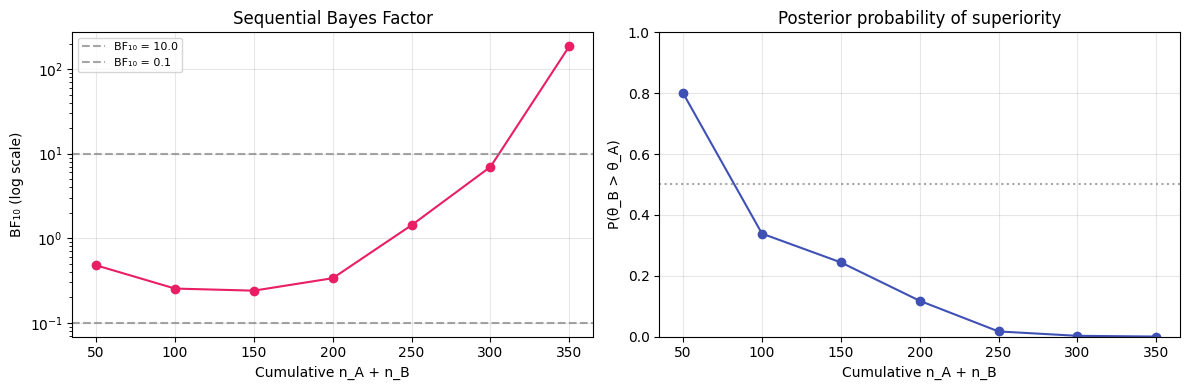

In [8]:
seq.plot_trajectory()

## 7. Sanity check: sequential = single-shot

Because the Beta–Bernoulli model is conjugate, fitting the cumulative data in one shot must produce **the same** posterior as the running sequential update. We verify this on the data the test consumed.

In [9]:
from bayesprop.resources.bayes_nonpaired import NonPairedBayesPropTest

# Reconstruct equivalent binary data from the sufficient statistics
# carried in the final snapshot (s successes + n-s failures per arm).
y_a_all = np.r_[np.ones(final.successes_A), np.zeros(final.n_A - final.successes_A)]
y_b_all = np.r_[np.ones(final.successes_B), np.zeros(final.n_B - final.successes_B)]

bb_batch = NonPairedBayesPropTest(alpha0=1.0, beta0=1.0, seed=0, n_samples=10_000).fit(
    y_a_all, y_b_all
)

print("Sequential posterior :", seq.posterior_state)
print("Single-shot posterior:",
      {"alpha_A": bb_batch.a_A, "beta_A": bb_batch.b_A,
       "alpha_B": bb_batch.a_B, "beta_B": bb_batch.b_B})

print(f"\nSequential P(B>A) = {final.P_B_greater_A:.6f}")
print(f"Batch      P(B>A) = {bb_batch.p_B_greater_A:.6f}")

Sequential posterior : {'alpha_A': 132.0, 'beta_A': 45.0, 'alpha_B': 98.0, 'beta_B': 79.0}
Single-shot posterior: {'alpha_A': np.float64(132.0), 'beta_A': np.float64(45.0), 'alpha_B': np.float64(98.0), 'beta_B': np.float64(79.0)}

Sequential P(B>A) = 0.000067
Batch      P(B>A) = 0.000067
